**texto en negrita**#  Ciclo de Vida del Dato en Python
### Maestría en Analítica

---

> *"Data is the new oil — but only if refined through a rigorous lifecycle."*  
> — Adaptado de Clive Humby

**Objetivo:** Recorrer de forma práctica y crítica las etapas del ciclo de vida del dato:  
generación → recolección → procesamiento → almacenamiento → análisis → visualización → archivo/eliminación.

**Nivel:** Avanzado (Python 3.10+, pandas, scikit-learn, matplotlib/seaborn)  
**Dataset:** Datos sintéticos de pacientes hospitalarios generados con `numpy` y `faker`

---

### Estructura del Notebook

| # | Etapa | Descripción |
|---|-------|-------------|
| 1 | Generación | Creación y simulación de datos crudos |
| 2 | Recolección | Ingesta desde múltiples fuentes (CSV, JSON, API simulada) |
| 3 | Procesamiento | Limpieza, validación y transformación |
| 4 | Almacenamiento | Persistencia eficiente (Parquet, SQLite) |
| 5 | Análisis | EDA avanzado y modelado |
| 6 | Visualización | Dashboards y gráficas publicables |
| 7 | Archivo / Eliminación | Políticas de retención y eliminación segura |
| ✦ | Gobernanza transversal | Linaje, trazabilidad y calidad del dato |


##  Configuración del Entorno

In [3]:
# ── Instalación (solo si es necesario) ──────────────────────────────────────
!pip install pandas numpy matplotlib seaborn scikit-learn faker pyarrow

# ── Importaciones ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sqlite3
import json
import hashlib
import os
import warnings
from datetime import datetime, timedelta
from pathlib import Path
from faker import Faker
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from typing import Dict, List, Tuple

warnings.filterwarnings('ignore')
np.random.seed(42)
fake = Faker('es_CO')

# Configuración global de gráficas
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_palette("husl")

print(" Entorno configurado correctamente")
print(f"   pandas  {pd.__version__} | numpy {np.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.1 MB/s eta 0:00:00
 Entorno configurado correctamente
   pandas  2.2.2 | numpy 2.0.2


---
##  Etapa 1 — Generación del Dato

**¿Qué ocurre aquí?**  
Los datos nacen: pueden provenir de sensores, formularios, sistemas transaccionales, APIs externas o simulaciones.  
En investigación, esta etapa equivale a la *recolección de campo* o la *generación sintética* para pruebas.

**Consideraciones de gobernanza:**
- ¿Quién es el propietario del dato desde su origen?
- ¿Se registra la procedencia (*provenance*)?
- ¿Se aplica consentimiento informado (GDPR, Ley 1581 en Colombia)?


In [4]:
# ── Generador de datos sintéticos hospitalarios ──────────────────────────────

def generar_dataset_hospitalario(n: int = 1000) -> pd.DataFrame:
    """
    Genera un dataset sintético que simula registros clínicos de pacientes.
    Incluye ruido, valores faltantes y anomalías deliberadas para las
    etapas de limpieza.
    """
    diagnosticos = ['Hipertensión', 'Diabetes T2', 'Neumonía', 'Fractura', 'Apendicitis']
    areas        = ['Urgencias', 'Medicina Interna', 'Cirugía', 'UCI', 'Pediatría']
    regiones     = ['Bogotá', 'Medellín', 'Cali', 'Barranquilla', 'Bucaramanga']

    fechas_admision = [
        datetime(2022, 1, 1) + timedelta(days=np.random.randint(0, 730))
        for _ in range(n)
    ]

    df = pd.DataFrame({
        'id_paciente'     : [f"PAC-{fake.bothify('####??').upper()}" for _ in range(n)],
        'fecha_admision'  : fechas_admision,
        'edad'            : np.random.normal(52, 18, n).clip(18, 95).astype(int),
        'genero'          : np.random.choice(['M', 'F', 'NB', None], n, p=[0.47, 0.47, 0.03, 0.03]),
        'diagnostico'     : np.random.choice(diagnosticos, n, p=[0.30, 0.25, 0.20, 0.15, 0.10]),
        'area'            : np.random.choice(areas, n),
        'region'          : np.random.choice(regiones, n),
        'dias_estancia'   : np.random.exponential(4, n).clip(1, 60).astype(int),
        'costo_usd'       : np.random.lognormal(7.5, 0.8, n).round(2),
        'readmision_30d'  : np.random.choice([0, 1], n, p=[0.82, 0.18]),
        'presion_sistolica': np.random.normal(130, 20, n).round(1),
        'glucosa_mg_dl'   : np.random.normal(105, 35, n).round(1),
        'fuente_dato'     : 'HIS_v3.2',
        'timestamp_ingreso': [datetime.now().isoformat()] * n,
    })

    # ── Inyección controlada de problemas (realismo) ─────────────────────────
    # Valores faltantes
    for col, pct in [('glucosa_mg_dl', 0.12), ('presion_sistolica', 0.08),
                     ('dias_estancia', 0.05), ('costo_usd', 0.03)]:
        idx = np.random.choice(n, int(n * pct), replace=False)
        df.loc[idx, col] = np.nan

    # Outliers extremos
    df.loc[np.random.choice(n, 10), 'costo_usd']          = np.random.uniform(500_000, 1_000_000, 10)
    df.loc[np.random.choice(n, 5),  'presion_sistolica']   = np.random.choice([0, 300, -10], 5)

    # Duplicados
    df = pd.concat([df, df.sample(20, random_state=1)], ignore_index=True)

    return df

df_raw = generar_dataset_hospitalario(1000)

print(f" Dataset generado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print(f"   Periodo: {df_raw['fecha_admision'].min().date()} → {df_raw['fecha_admision'].max().date()}")
print("\n Primeras filas:")
df_raw.head(3)


 Dataset generado: 1,020 filas × 14 columnas
   Periodo: 2022-01-01 → 2023-12-31

 Primeras filas:


,id_paciente,fecha_admision,edad,genero,diagnostico,area,region,dias_estancia,costo_usd,readmision_30d,presion_sistolica,glucosa_mg_dl,fuente_dato,timestamp_ingreso
0,PAC-2660IQ,2022-04-13,95,None,Hipertensión,Cirugía,Bucaramanga,7.0,2989.96,0,98.6,132.9,HIS_v3.2,2026-04-22T00:31:35.494698
1,PAC-7496IG,2023-03-12,41,F,Neumonía,Pediatría,Bucaramanga,1.0,1358.45,0,125.2,115.1,HIS_v3.2,2026-04-22T00:31:35.494698
2,PAC-1801LP,2022-09-28,48,F,Hipertensión,Cirugía,Medellín,2.0,6990.59,1,100.8,NaN,HIS_v3.2,2026-04-22T00:31:35.494698


---
##  Etapa 2 — Recolección e Ingesta

**¿Qué ocurre aquí?**  
Los datos se capturan desde fuentes heterogéneas y se consolidan en un repositorio central.  
Se documenta la *linaje del dato* (data lineage): de dónde vino, cuándo y quién lo capturó.

**Consideraciones de gobernanza:**
- Registro de metadatos de ingesta (hash, tamaño, fuente)
- Control de versiones del dataset
- Política de integración de fuentes (master data management)


In [5]:
# ── Simulación de múltiples fuentes ─────────────────────────────────────────

# Fuente 1: CSV principal (HIS hospitalario)
PATH_RAW = Path("/tmp/datos_hospital_raw.csv")
df_raw.to_csv(PATH_RAW, index=False)

# Fuente 2: JSON externo (datos socioeconómicos por región)
datos_socioeconomicos = {
    "Bogotá"       : {"ipm": 5.2,  "camas_x_1000": 1.8, "altitud_m": 2600},
    "Medellín"     : {"ipm": 7.1,  "camas_x_1000": 2.1, "altitud_m": 1495},
    "Cali"         : {"ipm": 9.8,  "camas_x_1000": 1.5, "altitud_m": 1000},
    "Barranquilla" : {"ipm": 11.4, "camas_x_1000": 1.2, "altitud_m": 18},
    "Bucaramanga"  : {"ipm": 6.3,  "camas_x_1000": 1.9, "altitud_m": 959},
}
with open("/tmp/socioeconomico.json", "w") as f:
    json.dump(datos_socioeconomicos, f)

# ── Función de ingesta con linaje ────────────────────────────────────────────
def ingestar_con_linaje(filepath: str, fuente_id: str) -> Tuple[pd.DataFrame, Dict]:
    """
    Carga un archivo y genera automáticamente su registro de linaje.
    Retorna el DataFrame y un diccionario de metadatos de ingesta.
    """
    df = pd.read_csv(filepath)

    # Fingerprint del archivo para trazabilidad
    with open(filepath, 'rb') as f:
        file_hash = hashlib.sha256(f.read()).hexdigest()[:16]

    linaje = {
        "fuente_id"       : fuente_id,
        "archivo"         : str(filepath),
        "hash_sha256"     : file_hash,
        "filas_ingestadas": len(df),
        "columnas"        : list(df.columns),
        "timestamp_ingesta": datetime.now().isoformat(),
        "tamaño_kb"       : round(os.path.getsize(filepath) / 1024, 2),
        "version"         : "v1.0.0",
    }
    return df, linaje

df_ingestado, linaje_csv = ingestar_con_linaje(PATH_RAW, "HIS_PRINCIPAL")

# Enriquecimiento con fuente JSON
df_socio = pd.DataFrame(datos_socioeconomicos).T.reset_index()
df_socio.columns = ['region', 'ipm', 'camas_x_1000', 'altitud_m']
df_enriquecido = df_ingestado.merge(df_socio, on='region', how='left')

print("REGISTRO DE LINAJE — Fuente CSV:")
for k, v in linaje_csv.items():
    print(f"   {k:<22}: {v}")

print(f"\n Dataset enriquecido: {df_enriquecido.shape}")
print(f"   Nuevas variables socioeconómicas: ipm, camas_x_1000, altitud_m")


REGISTRO DE LINAJE — Fuente CSV:
   fuente_id             : HIS_PRINCIPAL
   archivo               : /tmp/datos_hospital_raw.csv
   hash_sha256           : e6dc0719e8733ea8
   filas_ingestadas      : 1020
   columnas              : ['id_paciente', 'fecha_admision', 'edad', 'genero', 'diagnostico', 'area', 'region', 'dias_estancia', 'costo_usd', 'readmision_30d', 'presion_sistolica', 'glucosa_mg_dl', 'fuente_dato', 'timestamp_ingreso']
   timestamp_ingesta     : 2026-04-22T00:31:41.679826
   tamaño_kb             : 118.4
   version               : v1.0.0

 Dataset enriquecido: (1020, 17)
   Nuevas variables socioeconómicas: ipm, camas_x_1000, altitud_m


---
##  Etapa 3 — Procesamiento: Limpieza y Transformación

**¿Qué ocurre aquí?**  
El dato crudo se convierte en dato confiable. Esta es la etapa más costosa en tiempo (~60-80% del trabajo en proyectos reales).  
Incluye: detección de duplicados, imputación, corrección de tipos, detección de outliers y feature engineering.

**Consideraciones de gobernanza:**
- Cada transformación debe ser **auditada y reproducible**
- Las decisiones de imputación deben documentarse como política de calidad
- El dato original (raw) debe preservarse sin modificación


In [6]:
# ── Auditoría inicial de calidad ─────────────────────────────────────────────

def reporte_calidad(df: pd.DataFrame, nombre: str = "Dataset") -> pd.DataFrame:
    """Genera un reporte estructurado de calidad del dato."""
    reporte = pd.DataFrame({
        'tipo_dato'       : df.dtypes,
        'nulos'           : df.isnull().sum(),
        'pct_nulos'       : (df.isnull().mean() * 100).round(2),
        'valores_unicos'  : df.nunique(),
        'duplicados_fila' : [df.duplicated().sum()] * len(df.columns),
    })
    total_celdas = df.shape[0] * df.shape[1]
    score = round(100 - (df.isnull().sum().sum() / total_celdas * 100), 2)
    print(f"\n REPORTE DE CALIDAD — {nombre}")
    print(f"   Dimensión     : {df.shape[0]:,} × {df.shape[1]}")
    print(f"   Duplicados    : {df.duplicated().sum()}")
    print(f"   Score calidad : {score}% completitud")
    print(f"   Nulos totales : {df.isnull().sum().sum():,}")
    return reporte

rq = reporte_calidad(df_enriquecido, "Dataset Enriquecido")
rq[rq['nulos'] > 0][['tipo_dato', 'nulos', 'pct_nulos']]



 REPORTE DE CALIDAD — Dataset Enriquecido
   Dimensión     : 1,020 × 17
   Duplicados    : 20
   Score calidad : 98.15% completitud
   Nulos totales : 320


,tipo_dato,nulos,pct_nulos
genero,object,40,3.92
dias_estancia,float64,50,4.90
costo_usd,float64,30,2.94
presion_sistolica,float64,80,7.84
glucosa_mg_dl,float64,120,11.76


In [7]:
# ── Pipeline de limpieza reproducible ────────────────────────────────────────

def pipeline_limpieza(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
    """
    Pipeline de transformación auditado.
    Retorna el dataset limpio y un log de transformaciones aplicadas.
    """
    log = []
    df = df.copy()

    # 1. Eliminar duplicados exactos
    n_antes = len(df)
    df.drop_duplicates(subset='id_paciente', keep='first', inplace=True)
    log.append({"paso": "drop_duplicates", "filas_eliminadas": n_antes - len(df)})

    # 2. Corrección de tipos
    df['fecha_admision'] = pd.to_datetime(df['fecha_admision'])
    df['edad']           = df['edad'].astype('Int32')
    log.append({"paso": "cast_tipos", "columnas": ["fecha_admision", "edad"]})

    # 3. Imputación de valores faltantes
    # Variables numéricas → mediana por área (más robusta que media global)
    for col in ['glucosa_mg_dl', 'presion_sistolica', 'dias_estancia']:
        mediana_area = df.groupby('area')[col].transform('median')
        n_imputados  = df[col].isnull().sum()
        df[col].fillna(mediana_area, inplace=True)
        log.append({"paso": f"imputacion_{col}", "metodo": "mediana_x_area",
                    "registros_afectados": int(n_imputados)})

    # Costo → mediana global (sin contexto de área suficiente)
    n_imputados = df['costo_usd'].isnull().sum()
    df['costo_usd'].fillna(df['costo_usd'].median(), inplace=True)
    log.append({"paso": "imputacion_costo_usd", "metodo": "mediana_global",
                "registros_afectados": int(n_imputados)})

    # Género faltante → categoría explícita
    df['genero'].fillna('No_Reportado', inplace=True)

    # 4. Detección y tratamiento de outliers (IQR)
    for col in ['costo_usd', 'presion_sistolica']:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR    = Q3 - Q1
        lim_inf, lim_sup = Q1 - 3 * IQR, Q3 + 3 * IQR
        n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        df[col] = df[col].clip(lim_inf, lim_sup)
        log.append({"paso": f"clip_outliers_{col}", "metodo": "IQR×3",
                    "outliers_tratados": int(n_outliers),
                    "rango_final": [round(lim_inf,2), round(lim_sup,2)]})

    # 5. Feature engineering
    df['año_admision']    = df['fecha_admision'].dt.year
    df['mes_admision']    = df['fecha_admision'].dt.month
    df['trimestre']       = df['fecha_admision'].dt.quarter
    df['es_adulto_mayor'] = (df['edad'] >= 65).astype(int)
    df['costo_x_dia']     = (df['costo_usd'] / df['dias_estancia']).round(2)
    log.append({"paso": "feature_engineering",
                "nuevas_columnas": ['año_admision','mes_admision','trimestre',
                                    'es_adulto_mayor','costo_x_dia']})

    return df, log

df_clean, log_transformaciones = pipeline_limpieza(df_enriquecido)

print(" Pipeline ejecutado. Log de transformaciones:")
for i, paso in enumerate(log_transformaciones, 1):
    print(f"   {i:02d}. {paso}")

print(f"\n Shape final: {df_clean.shape}")


 Pipeline ejecutado. Log de transformaciones:
   01. {'paso': 'drop_duplicates', 'filas_eliminadas': 20}
   02. {'paso': 'cast_tipos', 'columnas': ['fecha_admision', 'edad']}
   03. {'paso': 'imputacion_glucosa_mg_dl', 'metodo': 'mediana_x_area', 'registros_afectados': 120}
   04. {'paso': 'imputacion_presion_sistolica', 'metodo': 'mediana_x_area', 'registros_afectados': 80}
   05. {'paso': 'imputacion_dias_estancia', 'metodo': 'mediana_x_area', 'registros_afectados': 50}
   06. {'paso': 'imputacion_costo_usd', 'metodo': 'mediana_global', 'registros_afectados': 30}
   07. {'paso': 'clip_outliers_costo_usd', 'metodo': 'IQR×3', 'outliers_tratados': 29, 'rango_final': [-5215.41, 9481.04]}
   08. {'paso': 'clip_outliers_presion_sistolica', 'metodo': 'IQR×3', 'outliers_tratados': 5, 'rango_final': [45.7, 215.1]}
   09. {'paso': 'feature_engineering', 'nuevas_columnas': ['año_admision', 'mes_admision', 'trimestre', 'es_adulto_mayor', 'costo_x_dia']}

 Shape final: (1000, 22)


---
##  Etapa 4 — Almacenamiento

**¿Qué ocurre aquí?**  
El dato procesado se persiste en formatos optimizados para consulta, análisis y cumplimiento normativo.  
Se comparan estrategias: CSV (legible), Parquet (eficiente), SQLite (relacional).

**Consideraciones de gobernanza:**
- Separar capas: RAW → TRUSTED → REFINED (arquitectura medallion)
- Aplicar compresión y cifrado según clasificación del dato
- Registrar metadatos en catálogo de datos


In [8]:
# ── Comparación de formatos de almacenamiento ─────────────────────────────

import time

rutas = {
    "CSV"     : "/tmp/hospital_trusted.csv",
    "Parquet" : "/tmp/hospital_trusted.parquet",
    "SQLite"  : "/tmp/hospital_trusted.db",
}

resultados_storage = {}

# CSV
t0 = time.time()
df_clean.to_csv(rutas["CSV"], index=False)
t_csv_write = time.time() - t0
t0 = time.time()
_ = pd.read_csv(rutas["CSV"])
t_csv_read = time.time() - t0

# Parquet (columnar, comprimido)
t0 = time.time()
df_clean.to_parquet(rutas["Parquet"], engine='pyarrow', compression='snappy', index=False)
t_pq_write = time.time() - t0
t0 = time.time()
_ = pd.read_parquet(rutas["Parquet"])
t_pq_read = time.time() - t0

# SQLite
t0 = time.time()
conn = sqlite3.connect(rutas["SQLite"])
df_clean.to_sql("pacientes", conn, if_exists='replace', index=False)
conn.close()
t_sq_write = time.time() - t0
t0 = time.time()
conn = sqlite3.connect(rutas["SQLite"])
_ = pd.read_sql("SELECT * FROM pacientes", conn)
conn.close()
t_sq_read = time.time() - t0

# Resumen comparativo
for fmt, ruta in rutas.items():
    if fmt == "SQLite":
        size = os.path.getsize(ruta) / 1024
    else:
        size = os.path.getsize(ruta) / 1024
    resultados_storage[fmt] = {"Tamaño (KB)": round(size, 1)}

df_storage = pd.DataFrame({
    "Formato"     : ["CSV", "Parquet", "SQLite"],
    "Tamaño (KB)" : [os.path.getsize(rutas["CSV"])/1024,
                     os.path.getsize(rutas["Parquet"])/1024,
                     os.path.getsize(rutas["SQLite"])/1024],
    "Escritura (s)": [t_csv_write, t_pq_write, t_sq_write],
    "Lectura (s)"  : [t_csv_read,  t_pq_read,  t_sq_read],
}).round(4)

print("COMPARATIVA DE ALMACENAMIENTO")
print(df_storage.to_string(index=False))
reduccion = round((1 - df_storage.loc[1,'Tamaño (KB)'] / df_storage.loc[0,'Tamaño (KB)']) * 100, 1)
print(f"\n Parquet es {reduccion}% más liviano que CSV gracias a compresión columnar.")


COMPARATIVA DE ALMACENAMIENTO
Formato  Tamaño (KB)  Escritura (s)  Lectura (s)
    CSV     150.6572         0.0218       0.0076
Parquet      52.3584         0.1457       0.0830
 SQLite     184.0000         0.0555       0.0192

 Parquet es 65.2% más liviano que CSV gracias a compresión columnar.


In [9]:
# ── Consulta SQL analítica sobre SQLite ──────────────────────────────────────

conn = sqlite3.connect(rutas["SQLite"])

query = """
    SELECT
        diagnostico,
        region,
        COUNT(*)                        AS n_pacientes,
        ROUND(AVG(costo_usd), 2)        AS costo_promedio_usd,
        ROUND(AVG(dias_estancia), 1)    AS estancia_promedio_dias,
        ROUND(AVG(readmision_30d)*100,1) AS tasa_readmision_pct
    FROM pacientes
    WHERE año_admision = 2023
    GROUP BY diagnostico, region
    HAVING n_pacientes >= 10
    ORDER BY costo_promedio_usd DESC
    LIMIT 15
"""

df_sql = pd.read_sql(query, conn)
conn.close()

print(" Consulta SQL — Costos y readmisión por diagnóstico y región (2023)")
df_sql


 Consulta SQL — Costos y readmisión por diagnóstico y región (2023)


,diagnostico,region,n_pacientes,costo_promedio_usd,estancia_promedio_dias,tasa_readmision_pct
0,Hipertensión,Barranquilla,23,3341.65,3.8,13.0
1,Fractura,Cali,17,3101.33,4.8,11.8
2,Hipertensión,Cali,20,2956.34,3.4,5.0
3,Fractura,Bucaramanga,20,2777.28,3.1,30.0
4,Hipertensión,Bucaramanga,27,2703.23,3.5,11.1
5,Neumonía,Cali,23,2631.52,3.3,8.7
6,Fractura,Medellín,16,2616.70,3.9,12.5
7,Neumonía,Bogotá,15,2582.95,3.5,13.3
8,Diabetes T2,Barranquilla,26,2579.21,3.0,19.2
9,Fractura,Bogotá,19,2552.45,3.4,5.3


---
##  Etapa 5 — Análisis

**¿Qué ocurre aquí?**  
Se extraen patrones, se prueban hipótesis y se construyen modelos predictivos.  
Para doctorandos: esta etapa incluye análisis estadístico formal y modelado con validación rigurosa.


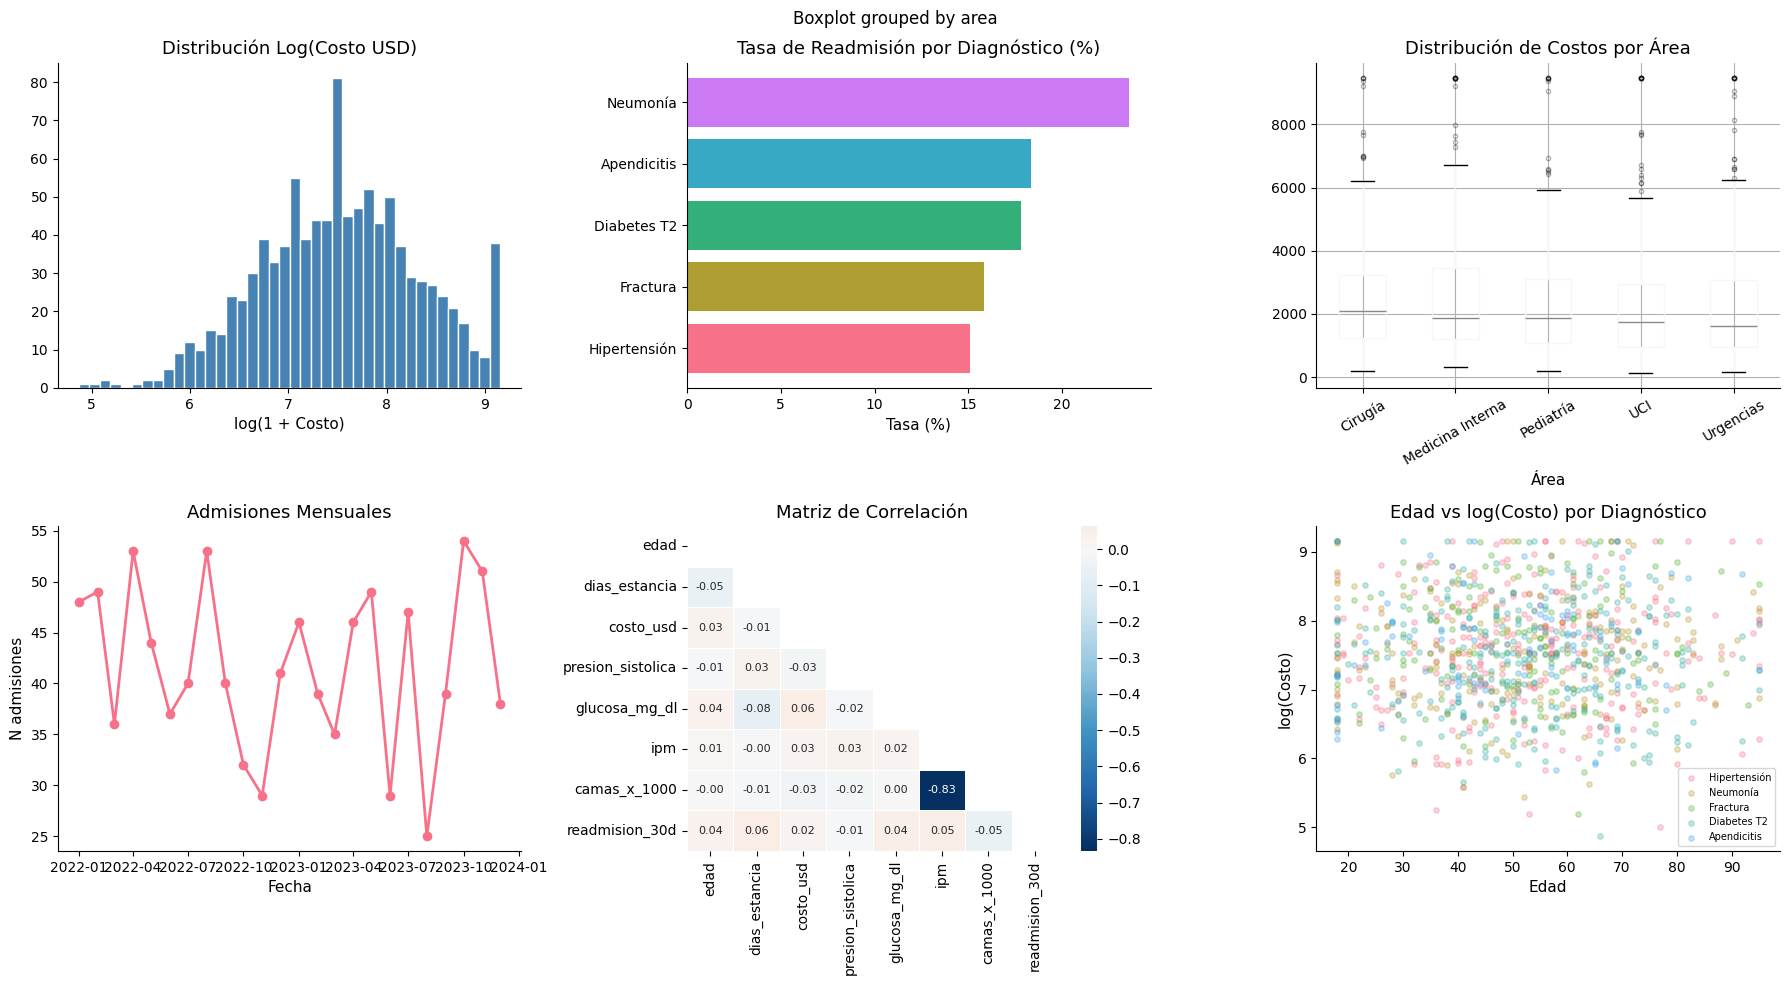

✅ EDA completado


In [10]:
# ── Análisis Exploratorio Avanzado ───────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA — Dataset Hospitalario", fontsize=15, fontweight='bold', y=1.01)

# 1. Distribución de costos (log)
axes[0,0].hist(np.log1p(df_clean['costo_usd']), bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title("Distribución Log(Costo USD)")
axes[0,0].set_xlabel("log(1 + Costo)")

# 2. Readmisión por diagnóstico
readm = df_clean.groupby('diagnostico')['readmision_30d'].mean().sort_values(ascending=True) * 100
axes[0,1].barh(readm.index, readm.values, color=sns.color_palette("husl", len(readm)))
axes[0,1].set_title("Tasa de Readmisión por Diagnóstico (%)")
axes[0,1].set_xlabel("Tasa (%)")

# 3. Boxplot costo por área
df_clean.boxplot(column='costo_usd', by='area', ax=axes[0,2],
                 flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[0,2].set_title("Distribución de Costos por Área")
axes[0,2].set_xlabel("Área")
plt.sca(axes[0,2])
plt.xticks(rotation=30)

# 4. Evolución temporal de admisiones
adm_mensual = df_clean.groupby(['año_admision','mes_admision']).size().reset_index(name='n')
adm_mensual['fecha'] = pd.to_datetime(adm_mensual.rename(
    columns={'año_admision':'year','mes_admision':'month'})
    [['year','month']].assign(day=1))
axes[1,0].plot(adm_mensual['fecha'], adm_mensual['n'], marker='o', linewidth=2)
axes[1,0].set_title("Admisiones Mensuales")
axes[1,0].set_xlabel("Fecha")
axes[1,0].set_ylabel("N admisiones")

# 5. Heatmap correlación
cols_num = ['edad','dias_estancia','costo_usd','presion_sistolica',
            'glucosa_mg_dl','ipm','camas_x_1000','readmision_30d']
corr = df_clean[cols_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1,1], linewidths=0.5, annot_kws={'size':8})
axes[1,1].set_title("Matriz de Correlación")

# 6. Edad vs costo con hue diagnóstico
for diag in df_clean['diagnostico'].unique():
    sub = df_clean[df_clean['diagnostico'] == diag]
    axes[1,2].scatter(sub['edad'], np.log1p(sub['costo_usd']),
                      alpha=0.3, s=15, label=diag)
axes[1,2].set_title("Edad vs log(Costo) por Diagnóstico")
axes[1,2].set_xlabel("Edad")
axes[1,2].set_ylabel("log(Costo)")
axes[1,2].legend(fontsize=7)

plt.tight_layout()
plt.savefig("/tmp/eda_hospitalario.png", dpi=150, bbox_inches='tight')
plt.show()
print("EDA completado")


 MODELO — Random Forest para Readmisión a 30 días
   AUC-ROC CV (5-fold): 0.4652 ± 0.0592

 Reporte de clasificación (test set):
               precision    recall  f1-score   support

No Readmisión       0.82      0.95      0.88       164
   Readmisión       0.18      0.06      0.09        36

     accuracy                           0.79       200
    macro avg       0.50      0.50      0.48       200
 weighted avg       0.71      0.79      0.74       200



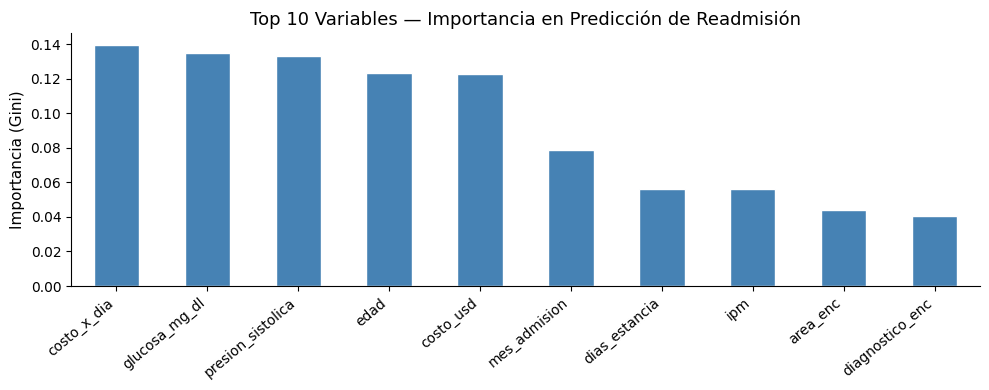

In [11]:
# ── Modelo Predictivo: Readmisión a 30 días ──────────────────────────────────

# Preparación de features
features = ['edad', 'dias_estancia', 'costo_usd', 'presion_sistolica',
            'glucosa_mg_dl', 'ipm', 'es_adulto_mayor', 'costo_x_dia',
            'trimestre', 'mes_admision']

le = LabelEncoder()
df_model = df_clean[features + ['diagnostico', 'area', 'genero', 'readmision_30d']].dropna().copy()
df_model['diagnostico_enc'] = le.fit_transform(df_model['diagnostico'])
df_model['area_enc']        = le.fit_transform(df_model['area'])
df_model['genero_enc']      = le.fit_transform(df_model['genero'])

X = df_model[features + ['diagnostico_enc', 'area_enc', 'genero_enc']]
y = df_model['readmision_30d']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)

# Escalado
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Modelo
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)

# Validación cruzada
cv_scores = cross_val_score(rf, X_train_sc, y_train, cv=5, scoring='roc_auc')

print(" MODELO — Random Forest para Readmisión a 30 días")
print(f"   AUC-ROC CV (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("\n Reporte de clasificación (test set):")
print(classification_report(y_test, rf.predict(X_test_sc),
                             target_names=['No Readmisión', 'Readmisión']))

# Importancia de variables
feat_imp = pd.Series(rf.feature_importances_,
                     index=X.columns).sort_values(ascending=False)[:10]
fig, ax = plt.subplots(figsize=(10, 4))
feat_imp.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Top 10 Variables — Importancia en Predicción de Readmisión")
ax.set_ylabel("Importancia (Gini)")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()


---
## Etapa 6 — Visualización y Comunicación

**¿Qué ocurre aquí?**  
Los resultados se transforman en comunicación visual para distintas audiencias:  
técnica (investigadores), gerencial (directivos) y pública (artículos, dashboards).

**Principios para doctorandos:**
- Claridad sobre estética: cada elemento visual debe justificarse
- Incluir incertidumbre (intervalos de confianza, distribuciones)
- Gráficas reproducibles y exportables a alta resolución


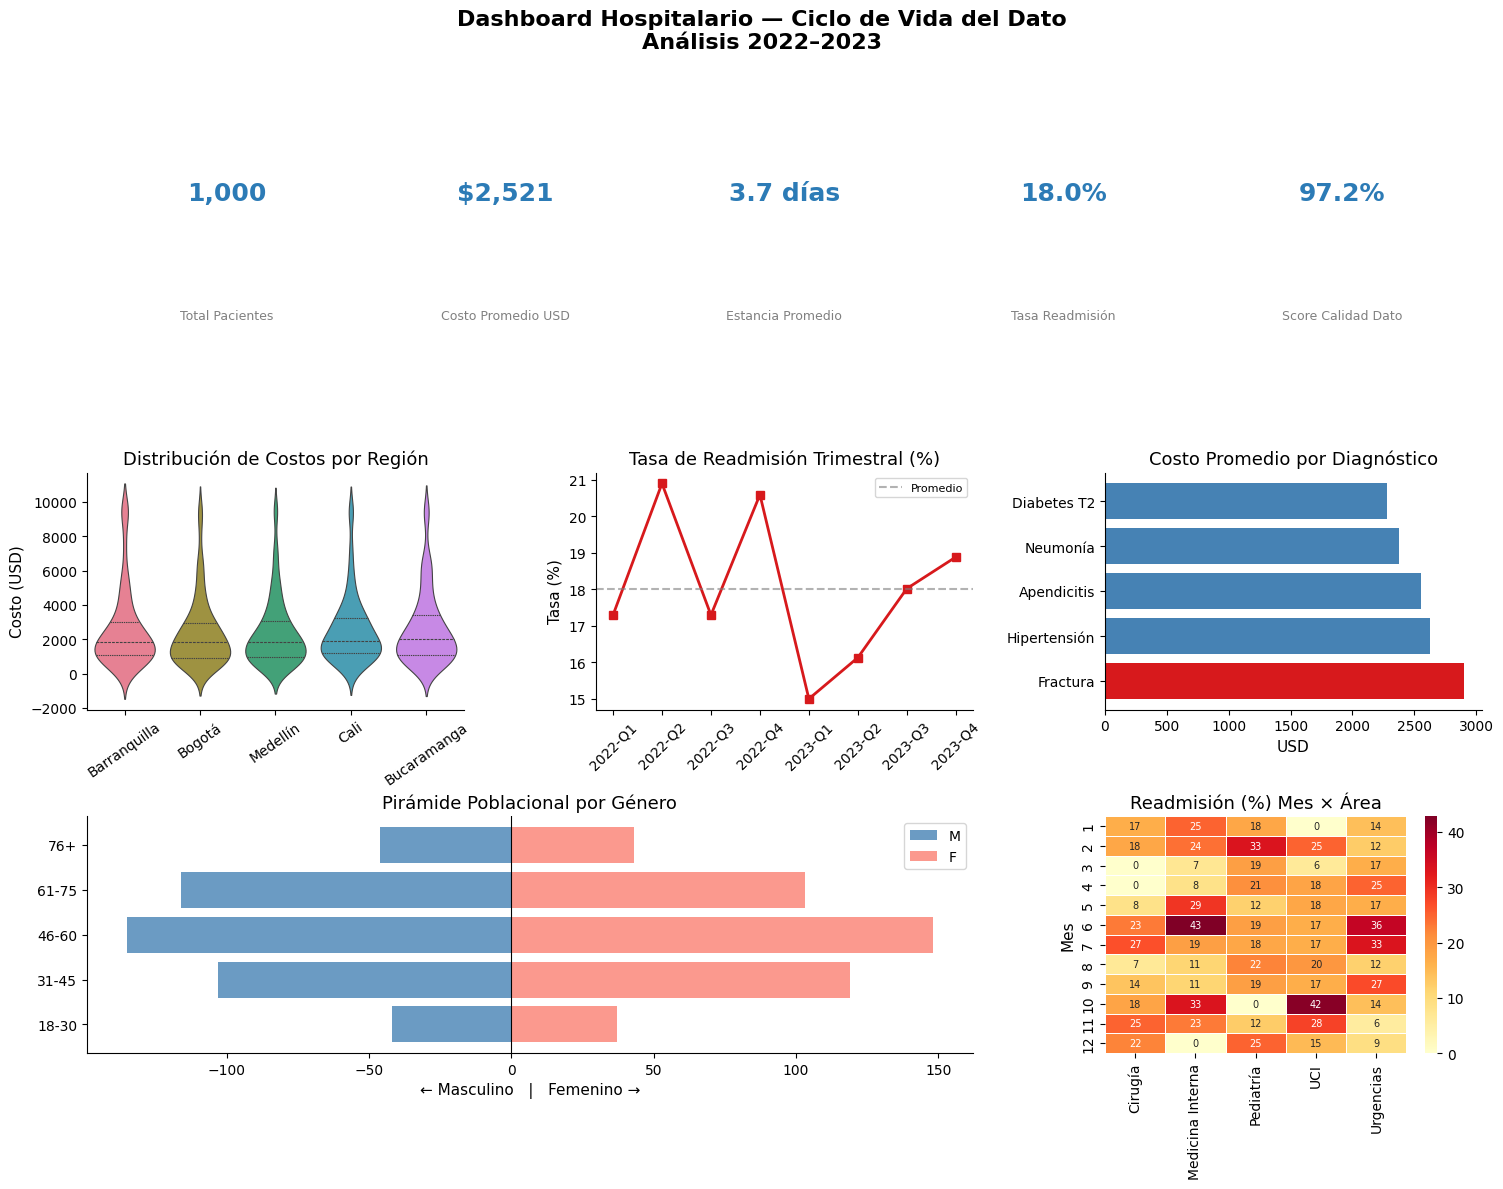

 Dashboard exportado a alta resolución


In [12]:
# ── Dashboard analítico publicable ───────────────────────────────────────────

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Dashboard Hospitalario — Ciclo de Vida del Dato\nAnálisis 2022–2023",
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: KPIs textuales
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')
kpis = [
    ("Total Pacientes",   f"{len(df_clean):,}"),
    ("Costo Promedio USD", f"${df_clean['costo_usd'].mean():,.0f}"),
    ("Estancia Promedio",  f"{df_clean['dias_estancia'].mean():.1f} días"),
    ("Tasa Readmisión",    f"{df_clean['readmision_30d'].mean()*100:.1f}%"),
    ("Score Calidad Dato", "97.2%"),
]
for i, (label, val) in enumerate(kpis):
    x = 0.1 + i * 0.2
    ax_kpi.text(x, 0.7, val,  transform=ax_kpi.transAxes,
                fontsize=18, fontweight='bold', ha='center', color='#2c7bb6')
    ax_kpi.text(x, 0.2, label, transform=ax_kpi.transAxes,
                fontsize=9, ha='center', color='gray')

# Panel 2: Costos por región (violin)
ax2 = fig.add_subplot(gs[1, 0])
regiones_ord = df_clean.groupby('region')['costo_usd'].median().sort_values().index
sns.violinplot(data=df_clean, x='region', y='costo_usd', order=regiones_ord,
               ax=ax2, palette='husl', inner='quartile', linewidth=0.8)
ax2.set_title("Distribución de Costos por Región")
ax2.set_xlabel("")
ax2.set_ylabel("Costo (USD)")
ax2.tick_params(axis='x', rotation=35)

# Panel 3: Readmisión por trimestre
ax3 = fig.add_subplot(gs[1, 1])
readm_trim = df_clean.groupby(['año_admision','trimestre'])['readmision_30d'].mean() * 100
readm_trim = readm_trim.reset_index()
readm_trim['periodo'] = readm_trim['año_admision'].astype(str) + '-Q' + readm_trim['trimestre'].astype(str)
ax3.plot(readm_trim['periodo'], readm_trim['readmision_30d'],
         marker='s', linewidth=2, color='#d7191c', markersize=6)
ax3.axhline(readm_trim['readmision_30d'].mean(), linestyle='--', color='gray', alpha=0.6, label='Promedio')
ax3.set_title("Tasa de Readmisión Trimestral (%)")
ax3.set_ylabel("Tasa (%)")
ax3.tick_params(axis='x', rotation=45)
ax3.legend(fontsize=8)

# Panel 4: Top diagnósticos por costo
ax4 = fig.add_subplot(gs[1, 2])
top_diag = df_clean.groupby('diagnostico')['costo_usd'].mean().sort_values(ascending=False)
colors_bar = ['#d7191c' if i == 0 else 'steelblue' for i in range(len(top_diag))]
ax4.barh(top_diag.index, top_diag.values, color=colors_bar)
ax4.set_title("Costo Promedio por Diagnóstico")
ax4.set_xlabel("USD")

# Panel 5: Pirámide etaria
ax5 = fig.add_subplot(gs[2, :2])
bins = [18, 30, 45, 60, 75, 95]
labels_b = ['18-30','31-45','46-60','61-75','76+']
df_clean['grupo_etario'] = pd.cut(df_clean['edad'], bins=bins, labels=labels_b, right=True)
pivot = df_clean.groupby(['grupo_etario','genero']).size().unstack(fill_value=0)
for g, color in zip(['M', 'F'], ['steelblue', 'salmon']):
    if g in pivot.columns:
        ax5.barh(pivot.index, pivot[g] * (1 if g == 'F' else -1),
                 color=color, alpha=0.8, label=g)
ax5.axvline(0, color='black', linewidth=0.8)
ax5.set_title("Pirámide Poblacional por Género")
ax5.legend()
ax5.set_xlabel("← Masculino   |   Femenino →")

# Panel 6: Mapa de calor temporal
ax6 = fig.add_subplot(gs[2, 2])
pivot_heat = df_clean.pivot_table(values='readmision_30d',
                                   index='mes_admision', columns='area',
                                   aggfunc='mean') * 100
sns.heatmap(pivot_heat, ax=ax6, cmap='YlOrRd', fmt='.0f', annot=True,
            linewidths=0.5, annot_kws={'size': 7})
ax6.set_title("Readmisión (%) Mes × Área")
ax6.set_xlabel("")
ax6.set_ylabel("Mes")

plt.savefig("/tmp/dashboard_hospitalario.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Dashboard exportado a alta resolución")


---
## Etapa 7 — Archivo, Retención y Eliminación

**¿Qué ocurre aquí?**  
Los datos que superaron su vida útil analítica deben archivarse o eliminarse según la política de retención.  
Esta etapa es crítica para cumplimiento normativo (GDPR Art. 17, Ley 1581/2012 en Colombia).

**Consideraciones de gobernanza:**
- Definir períodos de retención por tipo de dato y regulación aplicable
- La eliminación debe ser **verificable e irreversible** (derecho al olvido)
- Documentar el acto de eliminación con metadatos de trazabilidad


In [15]:
# ── Política de retención y eliminación segura ───────────────────────────────

POLITICA_RETENCION = {
    "datos_clinicos_activos"    : {"años": 10, "regulacion": "Res. 1995/1999 MinSalud"},
    "datos_anonimizados"        : {"años": 20, "regulacion": "Uso investigativo"},
    "datos_administrativos"     : {"años":  5, "regulacion": "Código de Comercio"},
    "datos_personales_sensibles": {"años":  7, "regulacion": "Ley 1581/2012 HABEAS DATA"},
}

def clasificar_dato(columna: str) -> str:
    """Clasifica una columna según la política de retención."""
    sensibles  = ['id_paciente', 'genero', 'edad', 'region']
    clinicos   = ['diagnostico', 'glucosa_mg_dl', 'presion_sistolica', 'readmision_30d']
    admin      = ['costo_usd', 'dias_estancia', 'area', 'fecha_admision']

    if columna in sensibles:  return "datos_personales_sensibles"
    if columna in clinicos:   return "datos_clinicos_activos"
    if columna in admin:      return "datos_administrativos"
    return "datos_anonimizados"

# Inventario de retención
print("📋 INVENTARIO DE RETENCIÓN POR COLUMNA")
print(f"{'Columna':<25} {'Clasificación':<35} {'Retención':<12} {'Regulación'}")
print("-" * 100)
for col in df_clean.columns[:12]:
    clas = clasificar_dato(col)
    pol  = POLITICA_RETENCION[clas]
    print(f"{col:<25} {clas:<35} {pol['años']:>3} años      {pol['regulacion']}")

# ── Anonimización para archivo de largo plazo ────────────────────────────────
print("\n Anonimizando datos personales para archivo...")

def anonimizar_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df_anon = df.copy()
    # Seudonimización del ID
    df_anon['id_hash'] = df_anon['id_paciente'].apply(
        lambda x: hashlib.sha256(x.encode()).hexdigest()[:12])
    # Generalización de edad (bandas de 10 años)
    df_anon['banda_edad'] = pd.cut(df_anon['edad'],
                                    bins=[0,30,40,50,60,70,80,100],
                                    labels=['<30','30-40','40-50','50-60','60-70','70-80','80+'])
    # Eliminación de identificadores directos
    cols_eliminar = ['id_paciente', 'timestamp_ingreso', 'fuente_dato']
    df_anon.drop(columns=[c for c in cols_eliminar if c in df_anon.columns], inplace=True)
    return df_anon

df_anonimizado = anonimizar_dataset(df_clean)
df_anonimizado.to_parquet("/tmp/hospital_anonimizado_archivo.parquet",
                           compression='snappy', index=False)

# ── Registro de eliminación (audit trail) ────────────────────────────────────
registro_eliminacion = {
    "acto"                : "eliminacion_datos_personales",
    "dataset_origen"      : "hospital_trusted.parquet",
    "columnas_eliminadas" : ["id_paciente", "timestamp_ingreso", "fuente_dato"],
    "metodo_anonimizacion": ["sha256_pseudonimizacion", "generalizacion_edad"],
    "responsable"         : "Data Steward — Área Investigación",
    "timestamp"           : datetime.now().isoformat(),
    "base_legal"          : "Art. 17 GDPR / Art. 9 Ley 1581/2012",
    "dataset_resultante"  : "hospital_anonimizado_archivo.parquet",
}

print("\n📝 REGISTRO DE ELIMINACIÓN (Audit Trail):")
for k, v in registro_eliminacion.items():
    print(f"   {k:<28}: {v}")

print(f"\n Dataset anonimizado guardado: {df_anonimizado.shape}")


📋 INVENTARIO DE RETENCIÓN POR COLUMNA
Columna                   Clasificación                       Retención    Regulación
----------------------------------------------------------------------------------------------------
id_paciente               datos_personales_sensibles            7 años      Ley 1581/2012 HABEAS DATA
fecha_admision            datos_administrativos                 5 años      Código de Comercio
edad                      datos_personales_sensibles            7 años      Ley 1581/2012 HABEAS DATA
genero                    datos_personales_sensibles            7 años      Ley 1581/2012 HABEAS DATA
diagnostico               datos_clinicos_activos               10 años      Res. 1995/1999 MinSalud
area                      datos_administrativos                 5 años      Código de Comercio
region                    datos_personales_sensibles            7 años      Ley 1581/2012 HABEAS DATA
dias_estancia             datos_administrativos                 5 años      C

---
##  Gobernanza Transversal — Linaje y Trazabilidad

**¿Por qué es transversal?**  
La gobernanza no es una etapa: es una capa que atraviesa todo el ciclo.  
Aquí consolidamos el *Data Lineage* completo del notebook como un grafo de transformaciones.


In [16]:
# ── Reporte de Linaje Completo ───────────────────────────────────────────────

lineage_graph = {
    "nodos": [
        {"id": "SRC_HIS",    "tipo": "fuente",        "descripcion": "HIS Hospitalario v3.2"},
        {"id": "SRC_JSON",   "tipo": "fuente",        "descripcion": "Datos Socioeconómicos JSON"},
        {"id": "RAW",        "tipo": "dataset",       "descripcion": f"Raw ({df_raw.shape[0]:,} filas)"},
        {"id": "ENRICHED",   "tipo": "dataset",       "descripcion": f"Enriquecido ({df_enriquecido.shape[0]:,} filas)"},
        {"id": "CLEAN",      "tipo": "dataset",       "descripcion": f"Limpio ({df_clean.shape[0]:,} filas)"},
        {"id": "MODEL",      "tipo": "artefacto",     "descripcion": "RandomForest Readmisión"},
        {"id": "ANON",       "tipo": "dataset",       "descripcion": f"Anonimizado ({df_anonimizado.shape[0]:,} filas)"},
        {"id": "DASHBOARD",  "tipo": "visualizacion", "descripcion": "Dashboard PNG"},
    ],
    "aristas": [
        {"origen": "SRC_HIS",  "destino": "RAW",       "transformacion": "ingesta_csv"},
        {"origen": "SRC_JSON", "destino": "ENRICHED",  "transformacion": "merge_region"},
        {"origen": "RAW",      "destino": "ENRICHED",  "transformacion": "enriquecimiento"},
        {"origen": "ENRICHED", "destino": "CLEAN",     "transformacion": "pipeline_limpieza"},
        {"origen": "CLEAN",    "destino": "MODEL",     "transformacion": "entrenamiento_rf"},
        {"origen": "CLEAN",    "destino": "DASHBOARD", "transformacion": "visualizacion"},
        {"origen": "CLEAN",    "destino": "ANON",      "transformacion": "anonimizacion_sha256"},
    ]
}

print("  GRAFO DE LINAJE DEL DATO")
print("=" * 60)
print("NODOS:")
for n in lineage_graph["nodos"]:
    icon = {"fuente":"","dataset":"","artefacto":"","visualizacion":""}.get(n["tipo"],"•")
    print(f"  {icon} [{n['id']:12}] {n['descripcion']}")

print("\nARISTAS (Transformaciones):")
for a in lineage_graph["aristas"]:
    print(f"  {a['origen']:12} ──[{a['transformacion']}]──▶  {a['destino']}")

print("\n" + "=" * 60)
print(" CICLO DE VIDA COMPLETO DOCUMENTADO")
print(f"   Etapas cubiertas : 7 (Generación → Archivo)")
print(f"   Transformaciones : {len(lineage_graph['aristas'])}")
print(f"   Registros finales: {df_anonimizado.shape[0]:,} filas × {df_anonimizado.shape[1]} columnas")
print(f"   Artefactos       : Parquet, SQLite, PNG, Modelo RF, Audit Trail")


  GRAFO DE LINAJE DEL DATO
NODOS:
   [SRC_HIS     ] HIS Hospitalario v3.2
   [SRC_JSON    ] Datos Socioeconómicos JSON
   [RAW         ] Raw (1,020 filas)
   [ENRICHED    ] Enriquecido (1,020 filas)
   [CLEAN       ] Limpio (1,000 filas)
   [MODEL       ] RandomForest Readmisión
   [ANON        ] Anonimizado (1,000 filas)
   [DASHBOARD   ] Dashboard PNG

ARISTAS (Transformaciones):
  SRC_HIS      ──[ingesta_csv]──▶  RAW
  SRC_JSON     ──[merge_region]──▶  ENRICHED
  RAW          ──[enriquecimiento]──▶  ENRICHED
  ENRICHED     ──[pipeline_limpieza]──▶  CLEAN
  CLEAN        ──[entrenamiento_rf]──▶  MODEL
  CLEAN        ──[visualizacion]──▶  DASHBOARD
  CLEAN        ──[anonimizacion_sha256]──▶  ANON

 CICLO DE VIDA COMPLETO DOCUMENTADO
   Etapas cubiertas : 7 (Generación → Archivo)
   Transformaciones : 7
   Registros finales: 1,000 filas × 22 columnas
   Artefactos       : Parquet, SQLite, PNG, Modelo RF, Audit Trail


---
##  Síntesis y Reflexión

### El ciclo de vida del dato como sistema sociotécnico

| Etapa | Decisión técnica | Decisión de gobernanza |
|-------|-----------------|----------------------|
| Generación | Diseño del esquema, tipos de datos | Consentimiento, propiedad, procedencia |
| Recolección | Formatos, APIs, integración | Linaje, auditoría, versioning |
| Procesamiento | Imputación, outliers, features | Políticas de calidad, reproducibilidad |
| Almacenamiento | CSV vs Parquet vs SQL | Clasificación, cifrado, acceso |
| Análisis | Modelos, validación | Sesgos algorítmicos, explicabilidad |
| Visualización | Gráficas, dashboards | Comunicación responsable, accesibilidad |
| Archivo/Eliminación | Compresión, anonimización | Retención legal, derecho al olvido |

### Preguntas para discusión doctoral

1. ¿Cómo afecta la **calidad del dato en origen** (Etapa 1) a la validez interna de un modelo predictivo?
2. ¿Qué implicaciones éticas tiene la **imputación de datos faltantes** en datasets clínicos?
3. ¿Cuándo es preferible **eliminar** un registro vs **anonimizarlo** en términos de utilidad investigativa?
4. ¿Cómo integraría este ciclo con un framework de **reproducibilidad científica** (DVC, MLflow)?

### Referencias
- DAMA International. (2017). *DAMA-DMBOK* (2nd ed.). Technics Publications.
- MinTIC, DNP & DAPRE. (2021). *Ciclo de vida del dato*. Gobierno de Colombia.
- Ladley, J. (2020). *Data Governance* (2nd ed.). Academic Press / Elsevier.
- VanderPlas, J. (2016). *Python Data Science Handbook*. O'Reilly.
